<a href="https://colab.research.google.com/github/fatimafateen14/CodeAlpha-Sales-Prediction/blob/main/Sales_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Cell 1 — Install & Import

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files

## Cell 2 — Upload & Load

In [2]:
uploaded = files.upload()  # upload Advertising.csv

df = pd.read_csv(list(uploaded.keys())[0], index_col=0)  # first col is just index
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
df.head()

Saving Advertising.csv to Advertising.csv
Shape: (200, 4)
Columns: ['TV', 'Radio', 'Newspaper', 'Sales']


,TV,Radio,Newspaper,Sales
1,230.1,37.8,69.2,22.1
2,44.5,39.3,45.1,10.4
3,17.2,45.9,69.3,9.3
4,151.5,41.3,58.5,18.5
5,180.8,10.8,58.4,12.9


## Cell 3 — EDA

<class 'pandas.core.frame.DataFrame'>
Index: 200 entries, 1 to 200
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 7.8 KB
None

Missing Values:
 TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

Statistical Summary:
                TV       Radio   Newspaper       Sales
count  200.000000  200.000000  200.000000  200.000000
mean   147.042500   23.264000   30.554000   14.022500
std     85.854236   14.846809   21.778621    5.217457
min      0.700000    0.000000    0.300000    1.600000
25%     74.375000    9.975000   12.750000   10.375000
50%    149.750000   22.900000   25.750000   12.900000
75%    218.825000   36.525000   45.100000   17.400000
max    296.400000   49.600000  114.000000   27.000000


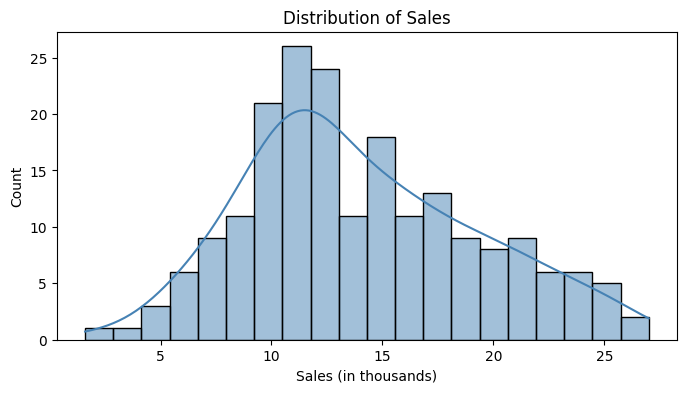

In [3]:
print(df.info())
print("\nMissing Values:\n", df.isnull().sum())
print("\nStatistical Summary:\n", df.describe())

# Distribution of Sales
plt.figure(figsize=(8, 4))
sns.histplot(df['Sales'], bins=20, kde=True, color='steelblue')
plt.title('Distribution of Sales')
plt.xlabel('Sales (in thousands)')
plt.show()

## Cell 4 — Correlation & Pairplot

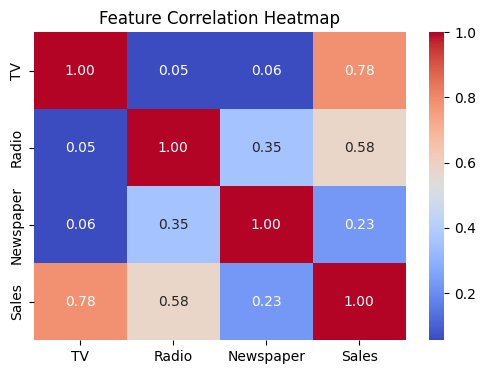

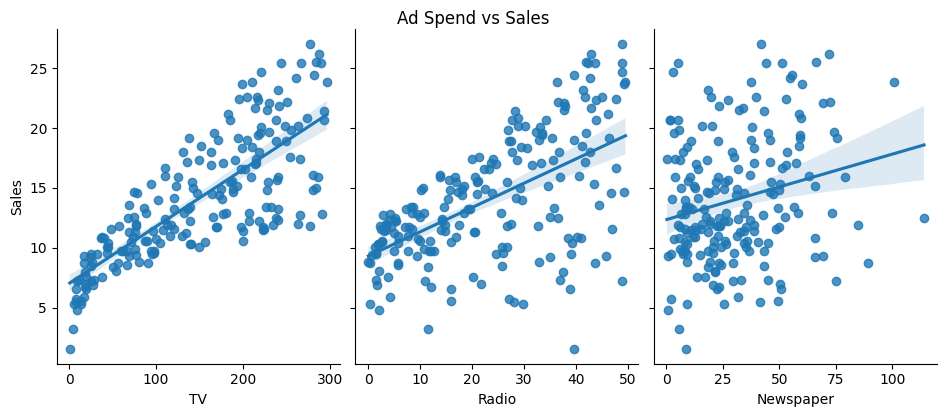

In [4]:
# Correlation heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.show()

# Pairplot to see relationships
sns.pairplot(df, x_vars=['TV', 'Radio', 'Newspaper'], y_vars='Sales',
             height=4, aspect=0.8, kind='reg')
plt.suptitle('Ad Spend vs Sales', y=1.02)
plt.show()

## Cell 5 — Feature & Target Split

In [5]:
X = df[['TV', 'Radio', 'Newspaper']]
y = df['Sales']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (200, 3)
Target shape: (200,)


## Cell 6 — Train/Test Split + Scaling

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Train: {X_train.shape} | Test: {X_test.shape}")

Train: (160, 3) | Test: (40, 3)


## Cell 7 — Train Multiple Models

In [7]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

models = {
    "Linear Regression"  : LinearRegression(),
    "Ridge Regression"   : Ridge(alpha=1.0),
    "Lasso Regression"   : Lasso(alpha=0.1),
    "Random Forest"      : RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting"  : GradientBoostingRegressor(n_estimators=100, random_state=42)
}

results = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)

    mae  = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2   = r2_score(y_test, preds)

    results[name] = {'MAE': round(mae,4), 'RMSE': round(rmse,4), 'R²': round(r2,4)}
    print(f"\n{name}:")
    print(f"  MAE={mae:.4f} | RMSE={rmse:.4f} | R²={r2:.4f}")


Linear Regression:
  MAE=1.4608 | RMSE=1.7816 | R²=0.8994

Ridge Regression:
  MAE=1.4643 | RMSE=1.7872 | R²=0.8988

Lasso Regression:
  MAE=1.4613 | RMSE=1.7913 | R²=0.8983

Random Forest:
  MAE=0.6207 | RMSE=0.7688 | R²=0.9813

Gradient Boosting:
  MAE=0.6181 | RMSE=0.7295 | R²=0.9831


## Cell 8 — Model Comparison Chart

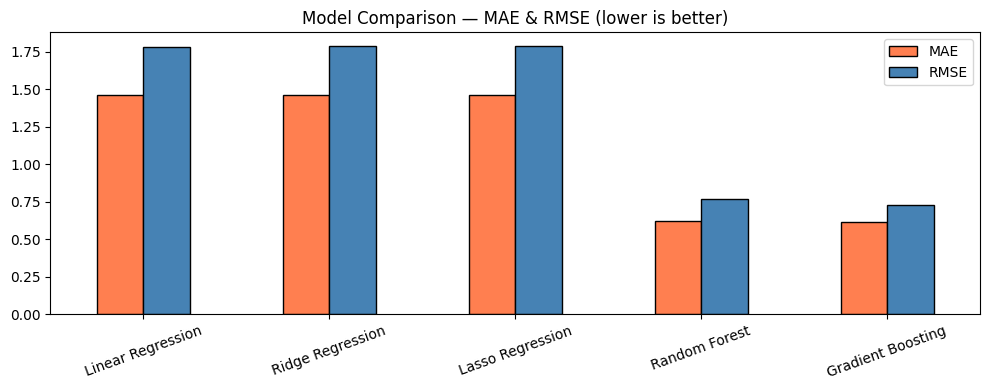


R² Scores (higher is better):
                       R²
Linear Regression  0.8994
Ridge Regression   0.8988
Lasso Regression   0.8983
Random Forest      0.9813
Gradient Boosting  0.9831


In [8]:
results_df = pd.DataFrame(results).T

results_df[['MAE', 'RMSE']].plot(kind='bar', figsize=(10, 4),
                                   color=['coral', 'steelblue'], edgecolor='black')
plt.title('Model Comparison — MAE & RMSE (lower is better)')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

print("\nR² Scores (higher is better):")
print(results_df[['R²']])

## Cell 9 — Actual vs Predicted (Best Model)

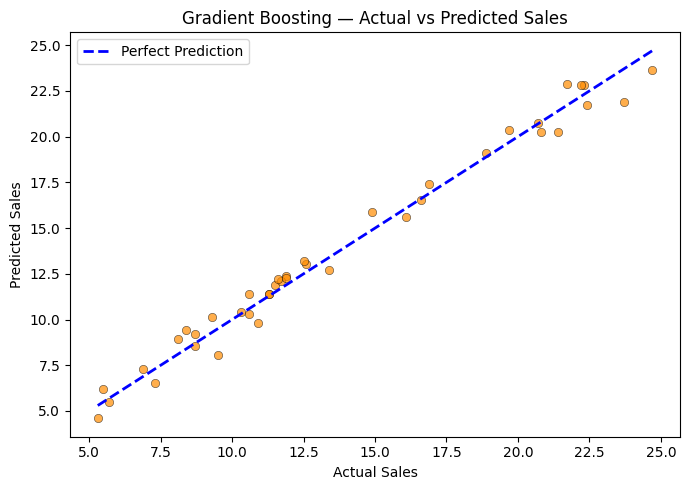

In [9]:
best_model = models["Gradient Boosting"]
y_pred = best_model.predict(X_test_scaled)

plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred, alpha=0.7, color='darkorange', edgecolors='black', linewidths=0.4)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'b--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.title('Gradient Boosting — Actual vs Predicted Sales')
plt.legend()
plt.tight_layout()
plt.show()

## Cell 10 — Ad Spend Impact Analysis (Business Insight)

/tmp/ipykernel_9357/1311810752.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=coeff_df, x='Channel', y='Coefficient', palette='viridis')


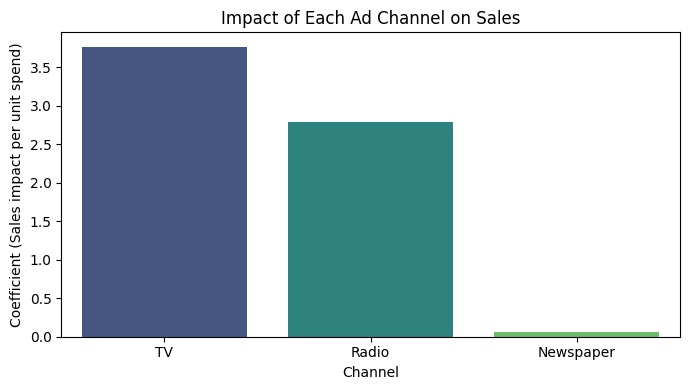

  Channel  Coefficient
       TV     3.764196
    Radio     2.792307
Newspaper     0.055976


In [10]:
# How each channel impacts sales — using Linear Regression coefficients
lr = models["Linear Regression"]
coeff_df = pd.DataFrame({
    'Channel'    : ['TV', 'Radio', 'Newspaper'],
    'Coefficient': lr.coef_
}).sort_values('Coefficient', ascending=False)

plt.figure(figsize=(7, 4))
sns.barplot(data=coeff_df, x='Channel', y='Coefficient', palette='viridis')
plt.title('Impact of Each Ad Channel on Sales')
plt.ylabel('Coefficient (Sales impact per unit spend)')
plt.tight_layout()
plt.show()

print(coeff_df.to_string(index=False))

## Cell 11 — Hyperparameter Tuning

In [11]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth'   : [3, 5, 7],
    'learning_rate': [0.05, 0.1, 0.2]
}

grid = GridSearchCV(
    GradientBoostingRegressor(random_state=42),
    param_grid, cv=5, scoring='r2', n_jobs=-1, verbose=1
)
grid.fit(X_train_scaled, y_train)

print("Best Params:", grid.best_params_)
print("Best CV R²:", round(grid.best_score_, 4))

tuned_pred = grid.best_estimator_.predict(X_test_scaled)
print("Tuned Test R²:", round(r2_score(y_test, tuned_pred), 4))

Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best Params: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 200}
Best CV R²: 0.9702
Tuned Test R²: 0.9742
